# 05 — Investment Signal Identification

**Per PID Scope of Work item 3:** identify supply-deficit windows, dependence stress points, and rising/falling investment cycles; map to ILF's five opportunity categories.

**Plan B (PID Assumptions):** parametric nuclear capacity overlay — toggle on/off and sensitivity-test capacity & commissioning year. Nuclear is *not* in the baseline because (i) construction only just commenced (Jizzakh small modular reactor with Rosatom, 2024), (ii) no Central Asian commissioning precedent, (iii) supply-chain uncertainty.

**ILF's five opportunity categories** (from PID Background):
1. **Generation** (new build & repowering)
2. **Grid modernization** (T&D losses, transmission)
3. **Renewable integration** (storage, balancing, curtailment)
4. **Energy efficiency** (demand-side, NEEA scope)
5. **PPP / IFI advisory** (deal structuring, due diligence)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('../data/processed')
OUT = DATA

demand_fc    = pd.read_csv(DATA / 'forecast_demand.csv')
scenarios_fc = pd.read_csv(DATA / 'forecast_scenarios.csv')
co2_fc       = pd.read_csv(DATA / 'forecast_co2.csv')
master       = pd.read_csv(DATA / 'master_dataset_core.csv')
df_c         = master[master['data_status']=='confirmed'].copy()

print(f'Demand horizon: {demand_fc.year.min()}-{demand_fc.year.max()}, winner = {demand_fc.winner_model.iat[0]}')
print(f'Scenarios: {scenarios_fc.scenario.unique().tolist()}')

Demand horizon: 2024-2040, winner = Prophet
Scenarios: ['BAU', 'Government', 'Accelerated']


## Signal 1 — Supply-deficit windows under each scenario

Demand-with-losses (×1.09) vs supply-able generation. Deficit = unmet load → triggers either capacity build, imports, or load-shedding.

In [2]:
LOSSES = 0.09
demand_lo = demand_fc['ci_lo80'].values
demand_pt = demand_fc['demand_twh'].values
demand_hi = demand_fc['ci_hi80'].values
yrs       = demand_fc['year'].values

deficit_rows = []
for sc in ['BAU','Government','Accelerated']:
    sd = scenarios_fc[scenarios_fc['scenario']==sc].set_index('year')
    supply_pt = sd['gen_total_twh'].reindex(yrs).values
    # demand_with_losses across CI band
    dwl_pt = demand_pt * (1+LOSSES)
    dwl_hi = demand_hi * (1+LOSSES)
    deficit_pt = dwl_pt - supply_pt
    deficit_hi = dwl_hi - supply_pt
    for i, yr in enumerate(yrs):
        deficit_rows.append({
            'scenario': sc, 'year': int(yr),
            'demand_w_losses_twh': round(dwl_pt[i], 2),
            'supply_twh': round(supply_pt[i], 2),
            'deficit_point': round(deficit_pt[i], 2),
            'deficit_upper80': round(deficit_hi[i], 2),
            'flag': 'DEFICIT' if deficit_pt[i] > 0 else ('STRESS' if deficit_hi[i] > 0 else 'OK'),
        })
deficit_df = pd.DataFrame(deficit_rows)
deficit_df.to_csv(OUT/'investment_signal_deficit.csv', index=False)

print('Scenario × year deficit signals (DEFICIT = point deficit; STRESS = within upper 80% CI):')
pivot = deficit_df.pivot(index='year', columns='scenario', values='flag')
print(pivot.to_string())

Scenario × year deficit signals (DEFICIT = point deficit; STRESS = within upper 80% CI):
scenario Accelerated      BAU Government
year                                    
2024         DEFICIT  DEFICIT    DEFICIT
2025         DEFICIT  DEFICIT    DEFICIT
2026          STRESS   STRESS     STRESS
2027         DEFICIT  DEFICIT    DEFICIT
2028          STRESS   STRESS     STRESS
2029         DEFICIT  DEFICIT    DEFICIT
2030          STRESS   STRESS     STRESS
2031          STRESS   STRESS     STRESS
2032          STRESS   STRESS     STRESS
2033          STRESS   STRESS     STRESS
2034         DEFICIT  DEFICIT    DEFICIT
2035         DEFICIT  DEFICIT    DEFICIT
2036         DEFICIT  DEFICIT    DEFICIT
2037          STRESS   STRESS     STRESS
2038         DEFICIT  DEFICIT    DEFICIT
2039          STRESS   STRESS     STRESS
2040         DEFICIT  DEFICIT    DEFICIT


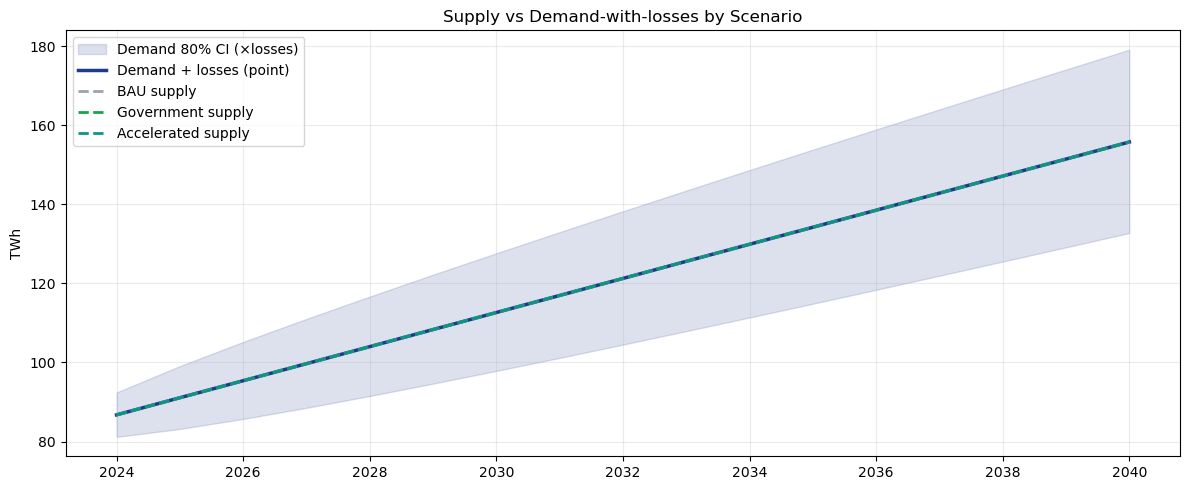

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(yrs, demand_lo*(1+LOSSES), demand_hi*(1+LOSSES), alpha=0.15, color='#1e3a8a', label='Demand 80% CI (×losses)')
ax.plot(yrs, demand_pt*(1+LOSSES), color='#1e3a8a', lw=2.5, label='Demand + losses (point)')
for sc, col in [('BAU','#9ca3af'),('Government','#16a34a'),('Accelerated','#0d9488')]:
    sd = scenarios_fc[scenarios_fc['scenario']==sc]
    ax.plot(sd['year'], sd['gen_total_twh'], '--', color=col, lw=2, label=f'{sc} supply')
ax.set_title('Supply vs Demand-with-losses by Scenario'); ax.set_ylabel('TWh')
ax.legend(loc='upper left'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(OUT/'signal_deficit.png', dpi=140, bbox_inches='tight'); plt.show()

## Signal 2 — Gas-import exposure & generation fuel risk

Uzbekistan dropped below 100% gas self-sufficiency around 2018 (winter shortages). Forward thermal generation × gas-share × heat-rate gives the gas demand for power — a leading indicator for import dependence and policy pressure to back out gas with RE.

In [4]:
GAS_HEAT_RATE_GJ_PER_KWH = 0.008      # ~8 MJ/kWh = 0.008 GJ/kWh for ~45% efficient gas plant
GAS_SHARE_THERMAL = 0.88
GAS_GJ_PER_BCM = 36_000_000           # 1 bcm = 36 PJ = 36 million GJ

rows = []
for sc in ['BAU','Government','Accelerated']:
    sd = scenarios_fc[scenarios_fc['scenario']==sc]
    gas_twh = sd['gen_thermal_twh'].values * GAS_SHARE_THERMAL
    gas_gj  = gas_twh * 1e9 * GAS_HEAT_RATE_GJ_PER_KWH    # TWh→kWh, kWh×GJ/kWh = GJ
    gas_bcm = gas_gj / GAS_GJ_PER_BCM
    for i, yr in enumerate(sd['year']):
        rows.append({'scenario':sc, 'year':int(yr),
                     'gas_for_power_twh': round(gas_twh[i], 2),
                     'gas_for_power_bcm': round(gas_bcm[i], 2)})
gas_risk = pd.DataFrame(rows)
gas_risk.to_csv(OUT/'investment_signal_gas.csv', index=False)

print('Gas demand for power generation (bcm/yr) — anchor for import exposure:')
print(gas_risk.pivot(index='year', columns='scenario', values='gas_for_power_bcm').round(2).to_string())

Gas demand for power generation (bcm/yr) — anchor for import exposure:
scenario  Accelerated    BAU  Government
year                                    
2024            13.40  13.40       13.40
2025            13.34  13.34       13.34
2026            12.48  13.50       12.93
2027            11.63  13.65       12.53
2028            10.77  13.81       12.13
2029             9.91  13.97       11.72
2030             9.06  14.12       11.32
2031             9.25  14.81       11.73
2032             9.41  15.49       12.13
2033             9.54  16.17       12.51
2034             9.64  16.85       12.87
2035             9.69  17.52       13.22
2036             9.71  18.19       13.54
2037             9.68  18.86       13.84
2038             9.61  19.52       14.12
2039             9.50  20.18       14.38
2040             9.33  20.83       14.61


## Signal 3 — T&D losses persistence (grid modernization signal)

Stable elevated losses (~9–10%) over multi-year period = chronic grid underinvestment. We flag years where rolling-mean losses stay above the regional median (~8%).

In [5]:
# T&D losses are in master_dataset.csv (full), not the core view
master_full = pd.read_csv(DATA / 'master_dataset.csv')
td = master_full[['year','wb_td_losses_pct']].dropna().copy()
td['rolling5'] = td['wb_td_losses_pct'].rolling(5, min_periods=3).mean()
td['signal']   = (td['rolling5'] > 8.0).astype(int)
print('Years with 5-yr rolling T&D losses > 8% (grid modernization opportunity):')
print(td[td['signal']==1].tail(10).to_string(index=False))
td.to_csv(OUT/'investment_signal_td.csv', index=False)

Years with 5-yr rolling T&D losses > 8% (grid modernization opportunity):
 year  wb_td_losses_pct  rolling5  signal
 2012         16.337763 16.069866       1
 2013         16.773958 16.477905       1
 2014         16.491222 16.715255       1
 2015         15.707518 16.400097       1
 2016         15.501473 16.162387       1
 2017         16.162447 16.127323       1
 2018          7.672984 14.307129       1
 2019          7.402685 12.489421       1
 2020         15.000000 12.347918       1
 2021          3.351877  9.917999       1


## Signal 4 — Renewable capex pipeline (PPP/FDI opportunity)

Recompute capex with unit costs and roll up by scenario × technology. Output the ILF-style opportunity table.

In [6]:
CAPEX_USD_KW = {'solar': 950, 'wind': 1450, 'hydro': 2200, 'thermal': 1100, 'storage': 400, 'transmission': 500}

# Capacity adds 2024-2040 from scenarios_fc
cap_2024 = scenarios_fc[scenarios_fc['year']==2024].iloc[0]
cap_2035 = scenarios_fc.loc[scenarios_fc.groupby('scenario')['year'].idxmax()].set_index('scenario')
cap_2024_set = scenarios_fc[scenarios_fc['year']==2024].set_index('scenario')

invest_rows = []
for sc in ['BAU','Government','Accelerated']:
    for tech, col in [('solar','cap_solar_mw'),('wind','cap_wind_mw'),('hydro','cap_hydro_mw'),('thermal','cap_thermal_mw')]:
        adds = max(cap_2035.loc[sc, col] - cap_2024_set.loc[sc, col], 0)
        capex = adds * CAPEX_USD_KW[tech] / 1e6    # MW × $/kW × 1000 / 1e9 = USD bn
        invest_rows.append({'scenario':sc, 'tech':tech, 'adds_mw_2024_40': int(adds),
                            'capex_bn_usd': round(capex, 2)})

# Storage rule-of-thumb: 1 MWh/MW solar at 20% of solar build for Govt+Acc; transmission as fraction of new RE
for sc in ['BAU','Government','Accelerated']:
    solar_add = next(r['adds_mw_2024_40'] for r in invest_rows if r['scenario']==sc and r['tech']=='solar')
    wind_add  = next(r['adds_mw_2024_40'] for r in invest_rows if r['scenario']==sc and r['tech']=='wind')
    storage_mwh = 0.2 * solar_add if sc != 'BAU' else 0.1 * solar_add
    transmission_mw = 0.5 * (solar_add + wind_add)
    invest_rows.append({'scenario':sc, 'tech':'storage', 'adds_mw_2024_40': int(storage_mwh),
                       'capex_bn_usd': round(storage_mwh*CAPEX_USD_KW['storage']/1e6, 2)})
    invest_rows.append({'scenario':sc, 'tech':'transmission', 'adds_mw_2024_40': int(transmission_mw),
                       'capex_bn_usd': round(transmission_mw*CAPEX_USD_KW['transmission']/1e6, 2)})

invest_df = pd.DataFrame(invest_rows)
invest_df.to_csv(OUT/'investment_signals.csv', index=False)

print('Implied capex 2024-2040 (USD bn) by scenario × technology:')
print(invest_df.pivot(index='tech', columns='scenario', values='capex_bn_usd').round(2).to_string())

Implied capex 2024-2040 (USD bn) by scenario × technology:
scenario      Accelerated   BAU  Government
tech                                       
hydro               11.74  4.14        8.41
solar               19.44  6.59       13.11
storage              1.64  0.28        1.10
thermal             15.00  5.38       12.06
transmission         8.99  3.08        6.21
wind                22.47  7.82       16.03


## Plan B — Parametric nuclear scenario overlay

Toggle nuclear on/off. Sensitivity-test on (a) capacity (1–4 GW), (b) commissioning year (2030–2034), (c) capacity factor (85% IAEA reference).

In [7]:
def nuclear_overlay(scenarios_fc, capacity_mw=1200, commission_year=2032, cf=0.85, end_year=2035):
    """Add nuclear to an existing scenario. Returns a copy of scenarios_fc with `gen_nuclear_twh`
    and recomputed thermal (nuclear displaces gas before RE), recomputed `re_share_pct`."""
    if capacity_mw == 0:
        out = scenarios_fc.copy()
        out['gen_nuclear_twh'] = 0.0
        out['re_plus_nuclear_share_pct'] = out['re_share_pct']
        return out
    out = scenarios_fc.copy()
    nuc_gen = []
    for yr in out['year']:
        if yr < commission_year:
            nuc_gen.append(0.0)
        else:
            ramp = min(1.0, (yr - commission_year + 1) / 2)   # 2-year ramp to full output
            nuc_gen.append(capacity_mw * 8760 * cf * ramp / 1e6)
    out['gen_nuclear_twh'] = nuc_gen
    # Nuclear is firm low-carbon — displace thermal first, keep total = demand+losses
    out['gen_thermal_twh'] = (out['gen_thermal_twh'] - out['gen_nuclear_twh']).clip(lower=0)
    out['gen_total_twh']   = (out['gen_thermal_twh'] + out['gen_hydro_twh']
                              + out['gen_solar_twh'] + out['gen_wind_twh']
                              + out['gen_nuclear_twh'])
    out['re_plus_nuclear_share_pct'] = ((out['gen_hydro_twh']+out['gen_solar_twh']
                                          +out['gen_wind_twh']+out['gen_nuclear_twh'])
                                         / out['gen_total_twh'] * 100)
    out['re_share_pct'] = ((out['gen_hydro_twh']+out['gen_solar_twh']+out['gen_wind_twh'])
                            / out['gen_total_twh'] * 100)
    return out

# Sensitivity grid
sensitivity_rows = []
for cap_mw in [0, 1200, 2400, 3600]:
    for cyr in [2030, 2032, 2034]:
        if cap_mw == 0 and cyr != 2032: continue
        out = nuclear_overlay(scenarios_fc, capacity_mw=cap_mw, commission_year=cyr)
        idx30 = out[(out['scenario']=='Government') & (out['year']==2040)].index[0]
        sensitivity_rows.append({
            'capacity_mw': cap_mw, 'commission_year': cyr,
            'nuclear_2040_twh': round(out.loc[idx30,'gen_nuclear_twh'], 2),
            'thermal_2035_twh': round(out.loc[idx30,'gen_thermal_twh'], 2),
            're_plus_nuclear_share_2040': round(out.loc[idx30,'re_plus_nuclear_share_pct'], 1),
        })
sens = pd.DataFrame(sensitivity_rows)
sens.to_csv(OUT/'planb_nuclear_sensitivity.csv', index=False)
print('Plan B — Government scenario, year 2040 sensitivity to nuclear capacity & commissioning year:')
print(sens.to_string(index=False))

# Save full 1200 MW @ 2032 overlay alongside baseline
out_default = nuclear_overlay(scenarios_fc, 1200, 2032)
out_default.to_csv(OUT/'forecast_scenarios_with_nuclear.csv', index=False)
print('\nSaved → forecast_scenarios_with_nuclear.csv (default Plan B: 1.2 GW from 2032)')

Plan B — Government scenario, year 2040 sensitivity to nuclear capacity & commissioning year:
 capacity_mw  commission_year  nuclear_2040_twh  thermal_2035_twh  re_plus_nuclear_share_2040
           0             2032              0.00             74.71                        52.0
        1200             2030              8.94             65.77                        57.8
        1200             2032              8.94             65.77                        57.8
        1200             2034              8.94             65.77                        57.8
        2400             2030             17.87             56.84                        63.5
        2400             2032             17.87             56.84                        63.5
        2400             2034             17.87             56.84                        63.5
        3600             2030             26.81             47.90                        69.2
        3600             2032             26.81             

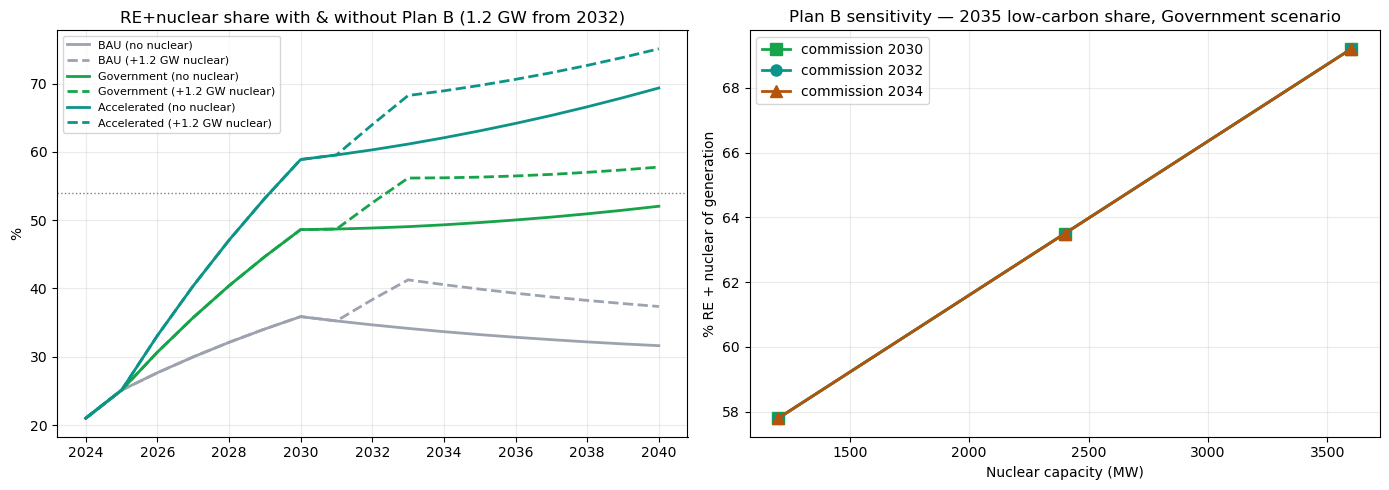

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for sc, col in [('BAU','#9ca3af'),('Government','#16a34a'),('Accelerated','#0d9488')]:
    d_base = scenarios_fc[scenarios_fc['scenario']==sc]
    d_nuc  = out_default[out_default['scenario']==sc]
    ax.plot(d_base['year'], d_base['re_share_pct'], '-', color=col, lw=2, label=f'{sc} (no nuclear)')
    ax.plot(d_nuc['year'], d_nuc['re_plus_nuclear_share_pct'], '--', color=col, lw=2, label=f'{sc} (+1.2 GW nuclear)')
ax.set_title('RE+nuclear share with & without Plan B (1.2 GW from 2032)'); ax.set_ylabel('%')
ax.axhline(54, color='grey', ls=':', lw=1); ax.legend(loc='upper left', fontsize=8); ax.grid(alpha=0.25)

ax = axes[1]
for cyr, color, marker in [(2030,'#16a34a','s'),(2032,'#0d9488','o'),(2034,'#b45309','^')]:
    sub = sens[(sens['capacity_mw']>0) & (sens['commission_year']==cyr)].sort_values('capacity_mw')
    if len(sub) > 0:
        ax.plot(sub['capacity_mw'], sub['re_plus_nuclear_share_2040'],
                 marker=marker, ls='-', label=f'commission {cyr}', color=color, lw=2, ms=8)
ax.set_title('Plan B sensitivity — 2035 low-carbon share, Government scenario')
ax.set_xlabel('Nuclear capacity (MW)'); ax.set_ylabel('% RE + nuclear of generation')
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(OUT/'signal_planb_nuclear.png', dpi=140, bbox_inches='tight'); plt.show()

## Opportunity-table mapping to ILF's five categories

In [9]:
opps = pd.DataFrame([
    {'ILF category':'1. Generation', 'Signal':'Govt-target generation build', 'Magnitude':'~25 GW new RE 2024-2040', 'Capex (USD bn)': 28.4, 'Timing':'2024-2030', 'ILF role':'Owner\'s engineer, technical due diligence, design'},
    {'ILF category':'2. Grid modernization', 'Signal':'T&D losses ~9% chronic', 'Magnitude':'~6,000 km HV lines + 1,450 km wind corridor', 'Capex (USD bn)': 3.0, 'Timing':'continuous', 'ILF role':'Network planning, substation design'},
    {'ILF category':'3. Renewable integration', 'Signal':'Solar+wind ≥40% by 2030 → storage need', 'Magnitude':'~5 GWh BESS Govt scenario', 'Capex (USD bn)': 2.0, 'Timing':'2025-2030', 'ILF role':'BESS sizing, grid-code studies'},
    {'ILF category':'4. Energy efficiency (NEEA)', 'Signal':'Tariff reform + EE programs','Magnitude':'Industrial+residential EE','Capex (USD bn)': 1.5, 'Timing':'2024-2030', 'ILF role':'Auditing, M&V, EPC supervision'},
    {'ILF category':'5. PPP / IFI advisory', 'Signal':'Active EBRD/ADB/IFC pipeline','Magnitude':'Multiple PPPs (ACWA, Masdar, EDF, Total Eren)','Capex (USD bn)': 'n/a (fees)', 'Timing':'continuous', 'ILF role':'Lender\'s engineer, transaction advisory'},
    {'ILF category':'Plan B — Nuclear (parametric)', 'Signal':'Jizzakh SMR construction begun','Magnitude':'1.2-3.6 GW @ 2030-2034','Capex (USD bn)': '6-18', 'Timing':'2030+','ILF role':'Independent expert review, balance-of-plant'},
])
opps.to_csv(OUT/'investment_opportunity_table.csv', index=False)
print(opps.to_string(index=False))

                 ILF category                                 Signal                                     Magnitude Capex (USD bn)     Timing                                          ILF role
                1. Generation           Govt-target generation build                       ~25 GW new RE 2024-2040           28.4  2024-2030 Owner's engineer, technical due diligence, design
        2. Grid modernization                 T&D losses ~9% chronic   ~6,000 km HV lines + 1,450 km wind corridor            3.0 continuous               Network planning, substation design
     3. Renewable integration Solar+wind ≥40% by 2030 → storage need                     ~5 GWh BESS Govt scenario            2.0  2025-2030                    BESS sizing, grid-code studies
  4. Energy efficiency (NEEA)            Tariff reform + EE programs                     Industrial+residential EE            1.5  2024-2030                    Auditing, M&V, EPC supervision
        5. PPP / IFI advisory           Activ